
### 1. Loading the data


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/Processed/EDA_dataset.csv')


### 2. General overview


In [4]:
print(df.shape)


(11196, 28)


In [5]:
print(df.columns.tolist())

['app_id', 'name', 'release_date', 'release_year', 'price_usd', 'price_steam', 'price_gog', 'steam_positive_pct', 'steam_total_reviews', 'steam_review_label', 'rawg_rating', 'metacritic', 'avg_playtime_hours', 'platforms_count', 'achievements_count', 'esrb_rating', 'gog_rating', 'gog_reviews_count', 'description', 'description_length', 'genres', 'tags', 'developer', 'is_free', 'has_description', 'has_rawg', 'has_gog', 'popularity_score_v2']


In [6]:
df.head()

,app_id,name,release_date,release_year,price_usd,price_steam,price_gog,steam_positive_pct,steam_total_reviews,steam_review_label,...,description,description_length,genres,tags,developer,is_free,has_description,has_rawg,has_gog,popularity_score_v2
0,3768760,007 First Light,2026-05-27,2026.0,80.873445,69.99,NaN,NaN,NaN,NaN,...,Earn the Number. 007 First Light is a thrillin...,41,"Action, Adventure","Singleplayer, Action, Adventure, Action-Advent...",IO Interactive A/S,0,1,0,0,0.001429
1,282800,100% Orange Juice,2014-05-16,2014.0,8.076945,6.99,NaN,94.0,8669.0,Very Positive,...,100% Orange Juice is a digital multiplayer boa...,37,"Indie, Strategy","Anime, Board Game, Cute, Multiplayer, Strategy...","Orange_Juice, Fruitbat Factory",0,1,0,0,0.904966
2,1895900,1348 Ex Voto,2026-03-12,2026.0,25.987195,22.49,NaN,52.0,477.0,Mixed,...,Journey through a tumultuous Medieval Italy as...,38,"Action, Adventure, Indie","Singleplayer, Third Person, Medieval, Action-A...",Sedleo,0,1,0,0,0.054930
3,1865060,14 Minesweeper Variants,2022-11-14,2022.0,8.076945,6.99,NaN,97.0,1462.0,Overwhelmingly Positive,...,Minesweeper but the rules are changing.,6,"Casual, Indie, Strategy","Puzzle, Logic, Minimalist, Experimental, Casua...","Alith Games, Artless Games",0,1,0,0,0.855127
4,1269370,171,2022-11-17,2022.0,23.098445,19.99,NaN,74.0,401.0,Mostly Positive,...,171 is an open world action adventure game wit...,13,"Action, Adventure, Indie, Early Access","Action, Indie, Open World, Crime, Gore, Shoote...",Betagames Group,0,1,0,0,0.195427


In [7]:
df.isnull().sum()

app_id                     0
name                       0
release_date               8
release_year               8
price_usd                 28
price_steam               29
price_gog               9230
steam_positive_pct        31
steam_total_reviews       31
steam_review_label        18
rawg_rating            11116
metacritic             11165
avg_playtime_hours     11116
platforms_count            0
achievements_count         0
esrb_rating            11156
gog_rating              9336
gog_reviews_count          0
description             2364
description_length         0
genres                    16
tags                       0
developer                  2
is_free                    0
has_description            0
has_rawg                   0
has_gog                    0
popularity_score_v2        0
dtype: int64

In [14]:
df[['popularity_score_v2', 'price_steam', 'steam_total_reviews', 'steam_positive_pct', 'platforms_count', 'achievements_count', 'description_length']].describe().round(2)

,popularity_score_v2,price_steam,steam_total_reviews,steam_positive_pct,platforms_count,achievements_count,description_length
count,11196.00,11167.00,11165.00,11165.00,11196.00,11196.00,11196.00
mean,0.50,15.43,5126.17,83.27,0.02,0.43,30.53
std,0.29,13.10,34966.05,12.59,0.33,10.39,25.14
min,0.00,0.00,10.00,15.00,0.00,0.00,0.00
25%,0.25,5.99,155.00,78.00,0.00,0.00,14.00
50%,0.50,12.49,676.00,86.00,0.00,0.00,34.00
75%,0.75,19.99,1904.00,93.00,0.00,0.00,44.00
max,1.00,269.99,2502519.00,100.00,10.00,684.00,783.00


We are not looking at all features because the rest are almost empty or not numeric


### 3. Target


What characteristics of the game most strongly influence its market popularity?

Our goal: to help investors and developers make informed decisions.

That is why our target variable is 'popularity_score_v2_v2_v2_v2_v2_v2'

In [16]:
import matplotlib.pyplot as plt

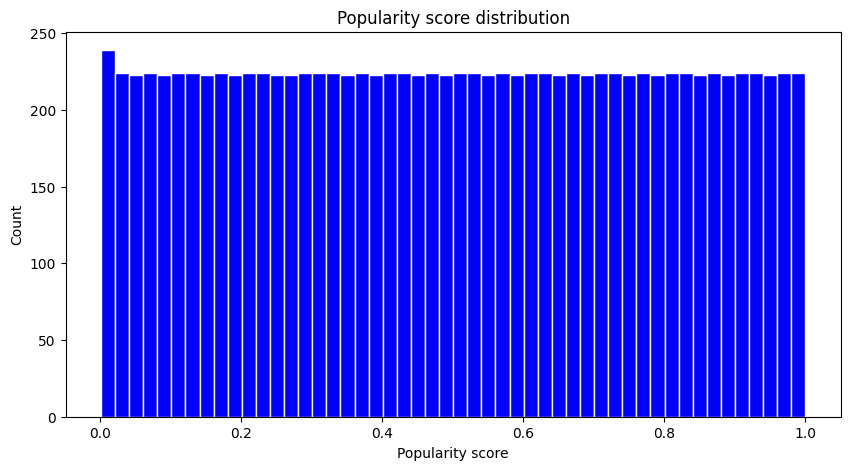

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df['popularity_score_v2'].dropna(), bins=50,
         color='blue', edgecolor='white')
plt.title('Popularity score distribution')
plt.xlabel('Popularity score')
plt.ylabel('Count')
plt.show()

This graph shows the distribution of values across all games. Looking to this graph, we can understand that the distribution in the game is uniform, which means that we can safely continue working with the target variable in order to objectively compare the success of games.

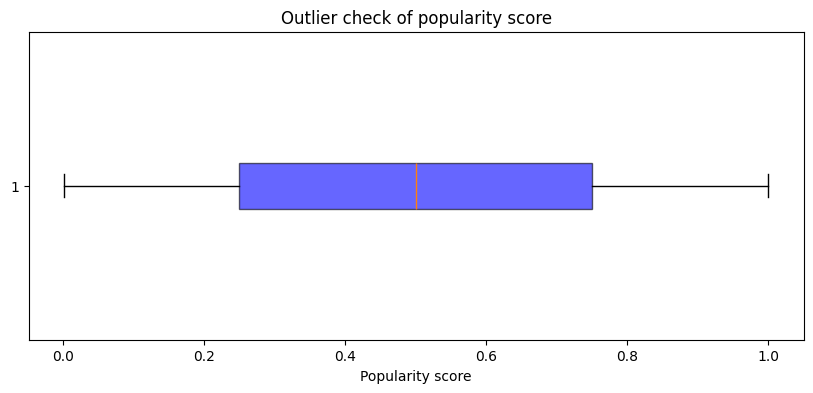

In [18]:
plt.figure(figsize=(10, 4))
plt.boxplot(df['popularity_score_v2'].dropna(), vert=False,
            patch_artist=True,
            boxprops=dict(facecolor='blue', alpha=0.6))
plt.title('Outlier check of popularity score')
plt.xlabel('Popularity score')
plt.show()

We can see that there are no outliers and it is distributed symmetrically.

### **4. Genre analysis**

In [19]:
df_genres = df[['genres', 'popularity_score_v2']].copy()
df_genres = df_genres.dropna()
df_genres['genres'] = df_genres['genres'].str.split(',')
df_genres = df_genres.explode('genres')
df_genres['genres'] = df_genres['genres'].str.strip()

In [20]:
df_genres_top = df_genres['genres'].value_counts().head(15)

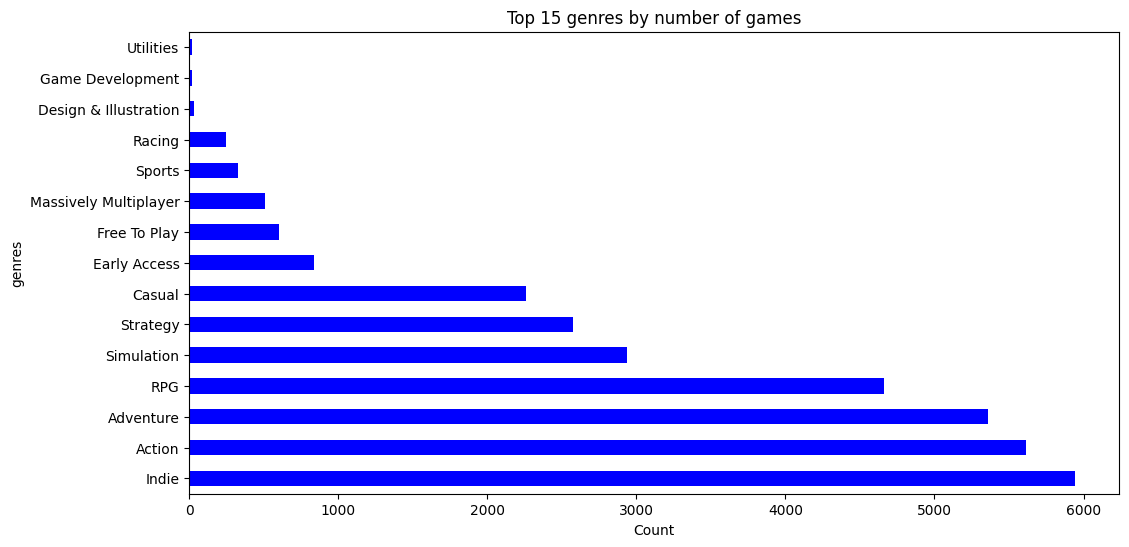

In [21]:
plt.figure(figsize=(12, 6))
df_genres_top.plot(kind='barh', color='blue')
plt.title('Top 15 genres by number of games')
plt.xlabel('Count')
plt.show()

This graph shows which genres are the most common. So, it can be understood that Indie is the most widespread genre, but Action and Adventure are also in huge demand, so perhaps an investor should focus on genres with less competition. For example, Simulation and RPG

In [22]:
genre_popularity = df_genres.groupby('genres')['popularity_score_v2'].mean().sort_values(ascending=False).head(15)

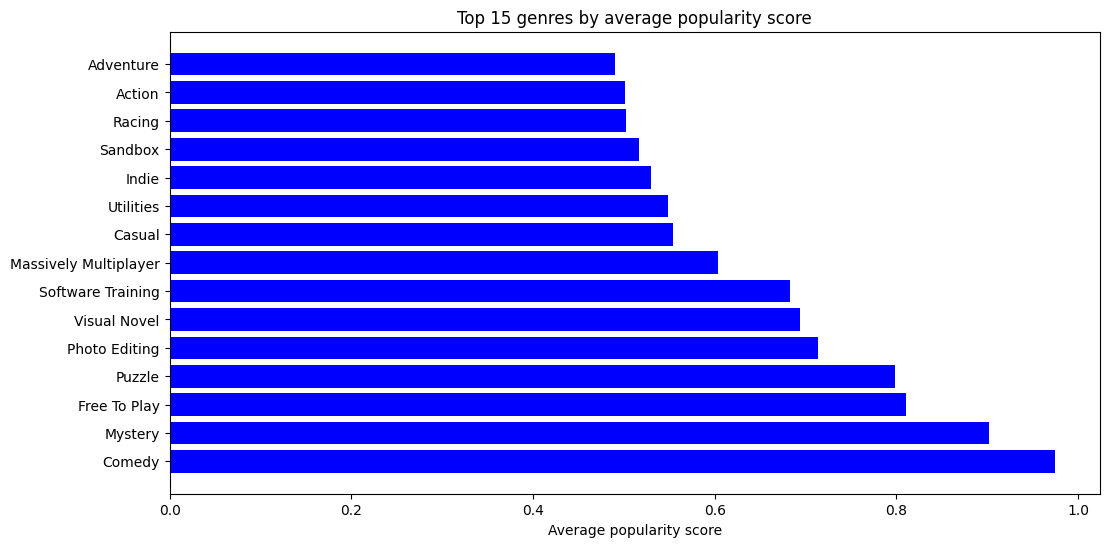

In [23]:
plt.figure(figsize=(12, 6))
plt.barh(genre_popularity.index, genre_popularity.values, color='blue')
plt.title('Top 15 genres by average popularity score')
plt.xlabel('Average popularity score')
plt.show()

Comedy, detective, and free-to-play have the highest average popularity score (0.8-1.0), despite the fact that they are not the most common genres. At the same time, adventure, action, and indie the most common genres show significantly lower average popularity (0.4-0.5). This confirms that high competition in the genre does not guarantee high popularity.


## 5. Price analysis

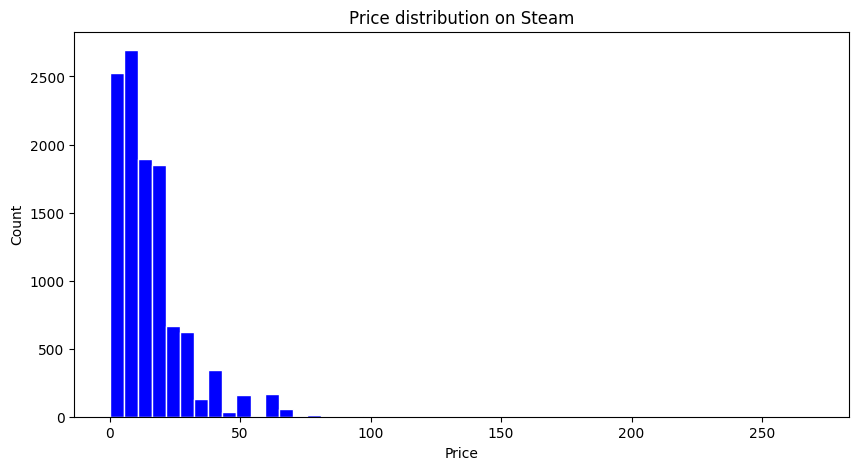

Number of free games:530
Number of paid games:10637
Average price:15.43
Median price:12.49


In [24]:
plt.figure(figsize=(10, 5))
plt.hist(df['price_steam'].dropna(), bins=50, color='blue', edgecolor='white')
plt.title('Price distribution on Steam')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

print(f'Number of free games:{(df['price_steam'] == 0).sum()}')
print(f'Number of paid games:{(df['price_steam'] > 0).sum()}')
print(f'Average price:{df['price_steam'].mean():.2f}')
print(f'Median price:{df['price_steam'].median():.2f}')


The market is dominated by the price segment up to 20 dollars. The median price is 12.49 dollars, which is where the maximum competition is. The premium segment (50+ dollars) is empty and it is a potential niche.

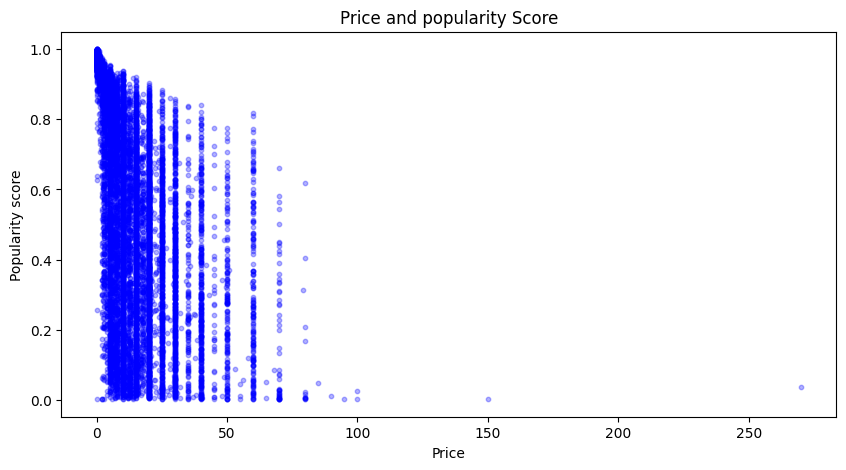

In [26]:
plt.figure(figsize=(10, 5))
plt.scatter(df['price_steam'], df['popularity_score_v2'], alpha=0.3, color='blue', s=10)
plt.title('Price and popularity Score')
plt.xlabel('Price')
plt.ylabel('Popularity score')
plt.show()

This chart shows the relationship between price and popularity. We may notice that the price does not determine the popularity of the game (at any price there are both hits and vice versa) This means that it is more important for an investor to look at the genre and quality, rather than the pricing strategy.

In [27]:
free_games = df[df['price_steam'] == 0]['popularity_score_v2']
paid_games = df[df['price_steam'] > 0]['popularity_score_v2']

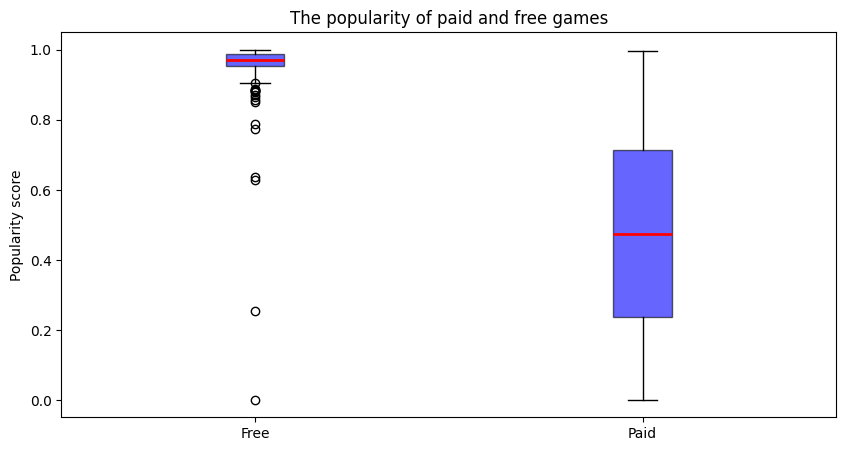

In [28]:
plt.figure(figsize=(10, 5))
plt.boxplot([free_games.dropna(), paid_games.dropna()], tick_labels=['Free', 'Paid'], patch_artist=True, boxprops=dict(facecolor='blue', alpha=0.6), medianprops=dict(color='red', linewidth=2))
plt.title('The popularity of paid and free games')
plt.ylabel('Popularity score')
plt.show()

Looking to free games: the box is small and high (0.9-1.0), the median is almost 1.0. But there are outliers down to 0.0, which means free games are mostly very popular, but sometimes they fail.

The paid box of the game is large, the median is about 0.45, the spread is from 0.2 to 0.7 and more even distribution.

Free games are on average more popular than paid ones, but this is can be a risky strategy. Paid games provide more predictable and stable results


### 6. Correlation matrix

In [30]:
import seaborn as sns

In [31]:
columns = ['popularity_score_v2', 'price_steam', 'steam_total_reviews',
        'steam_positive_pct', 'description_length']

corr = df[columns].corr()

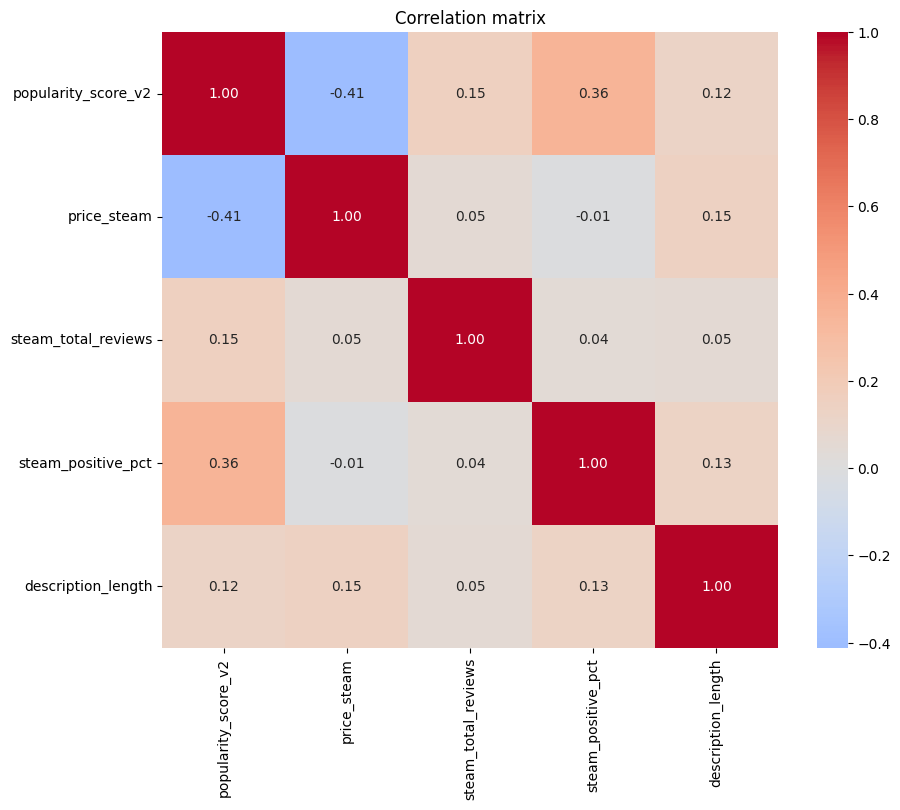

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation matrix')
plt.show()

price_steam (-0.41) and steam_positive_pct (0.36) have the strongest correlations with popularity_score_v2. This suggests that cheaper games and higher quality reviews (not just their quantity) are more related to popularity.
The number of reviews and the length of the description are poorly correlated.


### 7. Text analysis of descriptions


In [33]:
stopwords = {'the', 'a', 'an', 'and', 'or', 'in', 'on', 'at', 'to', 'for',
             'of', 'with', 'is', 'are', 'was', 'be', 'it', 'you', 'your',
             'this', 'that', 'as', 'by', 'from', 'their', 'its', 'can',
             'will', 'have', 'has', 'all', 'more', 'new', 'not', 'but',
             'game', 'play', 'player', 'players', 'world', 'get', 'use'}

In [34]:
import re

In [35]:
full_text = ' '.join(df['description'].dropna().astype(str))
words = re.findall(r'[a-zA-Z]{3,}', full_text.lower())
words_filtered = []
for word in words:
    if word not in stopwords:
        words_filtered.append(word)
top_words = pd.Series(words_filtered).value_counts().head(20)

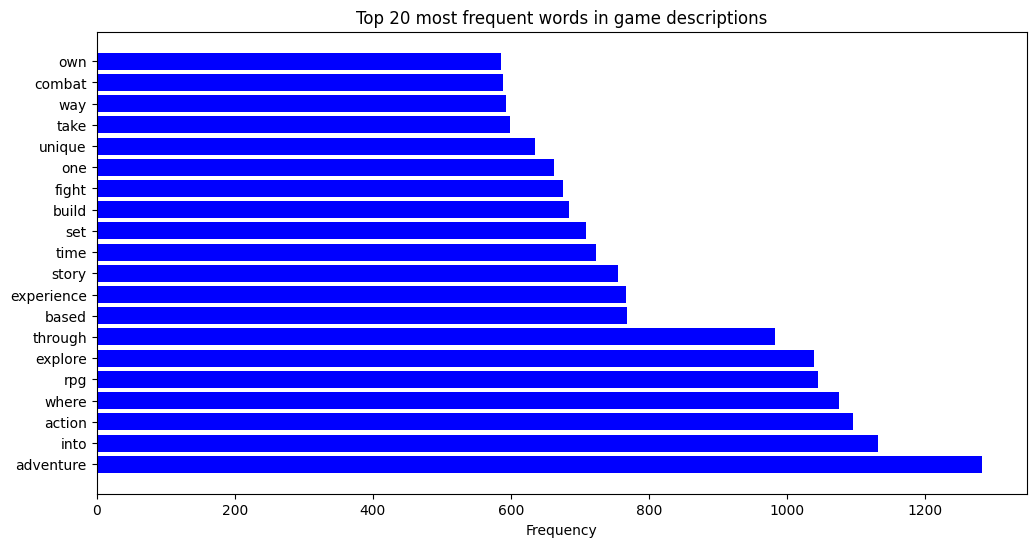

In [36]:
plt.figure(figsize=(12, 6))
plt.barh(top_words.index, top_words.values, color='blue')
plt.title('Top 20 most frequent words in game descriptions')
plt.xlabel('Frequency')
plt.show()

The descriptions of successful games emphasize the importance of adventure, world exploration, and unique experiences. Investors should pay attention to games with a rich story and an open world.


### 8. Analysis by year


In [37]:
year_data = df[df['release_year'] >= 2000].copy()
games_per_year = year_data['release_year'].value_counts().sort_index()

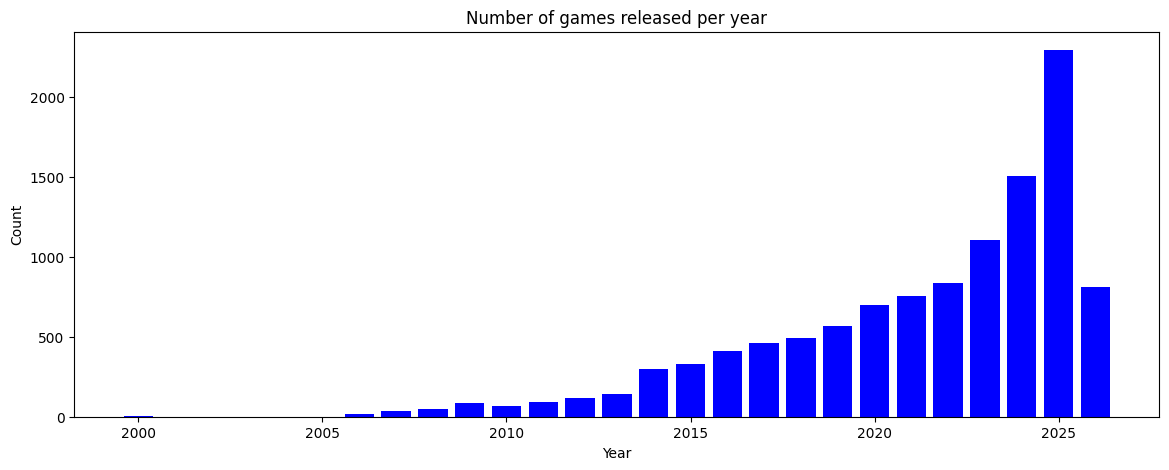

In [38]:
plt.figure(figsize=(14, 5))
plt.bar(games_per_year.index, games_per_year.values, color='blue')
plt.title('Number of games released per year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


Since 2012, the number of new games has increased 20-fold. This means high competition, but also huge demand. Investments in the gaming industry are very relevant.

### Hypotheses and conclusions

#### Hypothesis 1: Genre determines the popularity of a game

Based on the table 'Top 15 genres by average popularity score', the hypothesis is confirmed. Comedies, detective stories, and puzzles show the highest average popularity with less competition than Action and indie films.

Recommendation: Investors should pay attention to comedy and
Detective genres are highly popular with less saturation of the market.


#### Hypothesis 2: Free games are more popular than paid games.

Based on the 'The popularity of paid and free games' table, the hypothesis
is confirmed. The median popularity of free games is higher (approximately 0.95) compared to paid games (approximately 0.45).

Recommendation:  The free-to-play strategy with monetization is a high-reward approach, but more risky: free games show more extreme results (huge winnings or complete failure).


#### Hypothesis 3: Games with higher quality ratings are more popular

Based on the correlation matrix, the ratio between steam_positive_pct and popularity_score_v2 is 0.36, which is a moderate positive correlation.

Recommendation: Investors should prioritize game quality over marketing volume. A high percentage of positive reviews indicates player satisfaction and drives popularity growth.


#### Hypothesis 4: Games with longer and richer descriptions are more popular

Based on the correlation matrix, the relationship between the length of the description and popularity is 0.12. Judging by the frequency of words,
popular games most often use the words adventure, explore, experience,
story, they are focused on immersion and storytelling.

Recommendation: Descriptions may play a minor role. Games that focus on plot, exploration, and unique experiences tend to be more popular.



The most important factors of the game's popularity are:
1. Pricing strategy (price_steam: -0.41, cheaper games are more popular)
2. Review quality (steam_positive_pct: 0.36, higher ratings correlate with popularity)
3. Genre (comedy, mystery, puzzle - high average popularity)
4. Number of reviews (0.15 - community engagement matters)
5. Quality of description (0.12 - longer descriptions slightly correlate with success)
